字段说明：
id	标识符（唯一）
age	年龄
job	职业
marital	婚姻状况
education	教育程度
default	信用违约
balance	账户余额
housing	住房贷款
loan	个人贷款
contact	联系方式
day	联系日期
month	联系月份
duration	通话时长
campaign	活动联系次数
pdays	上次联系间隔
previous	之前联系次数
poutcome	之前活动结果
y	目标变量（客户是否订阅了定期存款(0=否, 1=是)）


其中，duration是一个强预测特征，但也是事后特征。通话时长只有在客户接听并沟通后才知道，而在拨打电话前我们是不知道的。如果模型用于“拨打电话前的筛选”，必须剔除该特征。如果模型用于“通话后分析客户意向”，则保留。所以基于业务需求，我们应该构建两个版本的模型。
用于因素分析的模型：

维度	解释
目的	分析影响转化的因素，理解客户行为
用途	洞察客户特征，优化营销模式
特点	包含duration，可以分析通话时长与转化的关系
用于预测的模型：

维度	解释
目的	预测哪些客户应该被联系
用途	客户筛选、优先级排序、优化效率、提高ROI
特点	不包含duration，使用营销前已知的特征
当然，也可以利用这份数据进行预设的预测客户是否订阅了定期存款，但是我觉得这没有什么实际价值，就不做了。

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr
#import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,RandomizedSearchCV,StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,roc_curve,recall_score, precision_score, f1_score, 
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#import lightgbm as lgb
import xgboost as xgb
#from imblearn.over_sampling import SMOTE
#from imblearn.pipeline import Pipeline as ImbPipeline
import time
import traceback
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

数据基本理解，数据展示

In [3]:
train = pd.read_csv(r"C:\Users\28621\Downloads\train.csv")
print(f"数据集大小: {train.shape}")
train.head()

数据集大小: (750000, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [5]:
train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [6]:
train.describe(include=['O'])

,job,marital,education,default,housing,loan,contact,month,poutcome
count,750000,750000,750000,750000,750000,750000,750000,750000,750000
unique,12,3,4,2,2,2,3,12,4
top,management,married,secondary,no,yes,no,cellular,may,unknown
freq,175541,480759,401683,737151,411288,645023,486655,228411,672450


In [7]:
# 查看目标变量分布
target_stats = pd.DataFrame({
    '数量': train['y'].value_counts(),
    '比例': train['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
})

print("目标变量分布统计:")
print(target_stats)

目标变量分布统计:
       数量      比例
y                
0  659512  87.93%
1   90488  12.07%


In [8]:
train.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
train.duplicated(keep='first').value_counts()

False    750000
Name: count, dtype: int64

因素分析

In [11]:
# 复制原数据集，避免修改原始数据
df = train.copy()

# 特征工程：处理上次联系间隔天数pdays字段
# 规则：pdays=-1代表从未联系过
# 1. 生成二分类特征：1=历史联系过客户，0=从未联系
df['contacted_before'] = (df['pdays'] != -1).astype(int)
# 2. 替换特殊值-1为999，统一数值格式适配模型训练
df['pdays_fixed'] = df['pdays'].replace(-1, 999)

# 通话时长单位转换：秒转为分钟，提升数据可读性与业务理解性
df['duration_minutes'] = df['duration'] / 60

# 输出新增特征基础统计信息
print("新特征创建完成:")
print(f"- contacted_before: {df['contacted_before'].sum()} 个客户之前被联系过")
print(f"- 平均通话时长: {df['duration_minutes'].mean():.2f} 分钟")

新特征创建完成:
- contacted_before: 77566 个客户之前被联系过
- 平均通话时长: 4.27 分钟


In [12]:
# 客户年龄分段分析

# 年龄分段
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25岁', '26-35岁', '36-45岁', '46-55岁', '56-65岁', '65岁以上']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_analysis = df.groupby('age_group', observed=True).agg(
    客户数量=('y', 'count'),           
    占比=('y', lambda x: len(x)/len(df)), 
    转化率=('y', 'mean')               
).reset_index()

age_analysis['占比'] = age_analysis['占比'].apply(lambda x: f"{x:.2%}")
age_analysis['转化率'] = age_analysis['转化率'].apply(lambda x: f"{x:.2%}")

print(age_analysis.to_string(index=False))

age_group   客户数量     占比    转化率
   18-25岁  16860  2.25% 26.92%
   26-35岁 260150 34.69% 13.04%
   36-45岁 233150 31.09%  9.64%
   46-55岁 164337 21.91%  9.14%
   56-65岁  67370  8.98% 15.26%
    65岁以上   8133  1.08% 52.19%


In [13]:
# 检验年龄组间差异
age_groups = [df[df['age_group'] == group]['y'] for group in df['age_group'].cat.categories]
f_stat, p_value = stats.f_oneway(*age_groups)
print(f"年龄组间差异ANOVA检验: F={f_stat:.2f}, p={p_value:.4f}")

年龄组间差异ANOVA检验: F=3970.67, p=0.0000


In [15]:
# 两两比较年龄组之间的转化率差异（Tukey显著性检验）
# 作用：判断哪些年龄组的转化率差异是“真实有效”的，不是随机误差
tukey = pairwise_tukeyhsd(df['y'], df['age_group'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
18-25岁 26-35岁  -0.1388   0.0 -0.1461 -0.1315   True
18-25岁 36-45岁  -0.1727   0.0   -0.18 -0.1654   True
18-25岁 46-55岁  -0.1777   0.0 -0.1852 -0.1703   True
18-25岁 56-65岁  -0.1166   0.0 -0.1245 -0.1087   True
18-25岁  65岁以上   0.2528   0.0  0.2404  0.2652   True
26-35岁 36-45岁  -0.0339   0.0 -0.0365 -0.0313   True
26-35岁 46-55岁   -0.039   0.0 -0.0419 -0.0361   True
26-35岁 56-65岁   0.0222   0.0  0.0183  0.0262   True
26-35岁  65岁以上   0.3916   0.0  0.3813  0.4019   True
36-45岁 46-55岁   -0.005   0.0  -0.008 -0.0021   True
36-45岁 56-65岁   0.0561   0.0  0.0521  0.0602   True
36-45岁  65岁以上   0.4255   0.0  0.4152  0.4358   True
46-55岁 56-65岁   0.0612   0.0   0.057  0.0654   True
46-55岁  65岁以上   0.4305   0.0  0.4201  0.4409   True
56-65岁  65岁以上   0.3694   0.0  0.3586  0.3801   True
---------------------------------------------------


所有年龄组之间的转化率差异均显著，年龄分组对转化率有极强的显著影响。
老年客户（65岁以上）转化率最高，中年客户（46-55岁）转化率最低，建议资源向两端倾斜，重点服务高价值老年客户，针对性破解中年客户转化难题。

In [16]:
# 客户余额水平分析
# 余额分段
df['balance_level'] = pd.cut(df['balance'], 
                             bins=[-np.inf, 0, 500, 2000, 5000, np.inf],
                             labels=['负余额', '0-500', '500-2000', '2000-5000', '5000以上'])

balance_analysis = df.groupby('balance_level', observed=True).agg(
    客户数量=('y', 'count'),                 
    占比=('y', lambda x: len(x)/len(df)),    
    转化率=('y', 'mean')                     
).reset_index()

# 格式化输出
balance_analysis['占比'] = balance_analysis['占比'].apply(lambda x: f"{x:.2%}")
balance_analysis['转化率'] = balance_analysis['转化率'].apply(lambda x: f"{x:.2%}")

print(balance_analysis.to_string(index=False))

balance_level   客户数量     占比    转化率
          负余额 197804 26.37%  3.53%
        0-500 113809 15.17%  9.91%
     500-2000 309051 41.21% 14.08%
    2000-5000 100289 13.37% 20.40%
       5000以上  29047  3.87% 28.41%


In [17]:
# 检验余额组间差异
balance_groups = [df[df['balance_level'] == group]['y'] for group in df['balance_level'].cat.categories]
f_stat, p_value = stats.f_oneway(*balance_groups)
print(f"余额组间差异ANOVA检验: F={f_stat:.2f}, p={p_value:.4f}")

余额组间差异ANOVA检验: F=7583.23, p=0.0000


In [18]:
tukey_balance = pairwise_tukeyhsd(df['y'], df['balance_level'], alpha=0.05)
print(tukey_balance)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj  lower   upper  reject
---------------------------------------------------------
    0-500 2000-5000   0.1049   0.0  0.1011  0.1087   True
    0-500  500-2000   0.0418   0.0  0.0388  0.0448   True
    0-500    5000以上    0.185   0.0  0.1793  0.1907   True
    0-500       负余额  -0.0638   0.0  -0.067 -0.0606   True
2000-5000  500-2000  -0.0631   0.0 -0.0663   -0.06   True
2000-5000    5000以上   0.0801   0.0  0.0743  0.0859   True
2000-5000       负余额  -0.1687   0.0 -0.1721 -0.1653   True
 500-2000    5000以上   0.1432   0.0  0.1379  0.1486   True
 500-2000       负余额  -0.1056   0.0 -0.1081 -0.1031   True
   5000以上       负余额  -0.2488   0.0 -0.2543 -0.2433   True
---------------------------------------------------------


所有余额组之间的转化率差异均显著，余额分组对转化率有极强的显著影响。
余额5000以上对比负余额转化率高出24.9%，所有分组对比符合现实。

In [19]:
total_customers = len(df)
print("\n按转化状态分组的统计信息:")
print(df.groupby('y')['duration_minutes'].describe())

# 检查极端值
print("\n极端通话情况:")
count_30 = df[df['duration_minutes'] > 30].shape[0]
pct_30 = count_30 / total_customers * 100
print(f">30分钟: {count_30} 个客户 ({pct_30:.3f}%)")

count_60 = df[df['duration_minutes'] > 60].shape[0]
pct_60 = count_60 / total_customers * 100
print(f">60分钟: {count_60} 个客户 ({pct_60:.3f}%)")


按转化状态分组的统计信息:
      count       mean       std       min       25%    50%    75%        max
y                                                                            
0  659512.0   3.396726  3.518915  0.016667  1.450000   2.05   3.30  81.933333
1   90488.0  10.638787  5.887494  0.016667  5.966667  10.15  14.25  81.966667

极端通话情况:
>30分钟: 465 个客户 (0.062%)
>60分钟: 30 个客户 (0.004%)


In [20]:
r, p = pearsonr(df['duration_minutes'], df['y'])
print(f"Pearson r={r:.4f}, p={p:.4f}")

Pearson r=0.5193, p=0.0000


In [21]:
# 单变量逻辑回归
X = sm.add_constant(df['duration_minutes'])
y = df['y']
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.264365
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               750000
Model:                          Logit   Df Residuals:                   749998
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2820
Time:                        15:03:23   Log-Likelihood:            -1.9827e+05
converged:                       True   LL-Null:                   -2.7616e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.7482      0.008   -488.580      0.000      -3.763      -3.733
duration_mi

通话时长每增加1分钟，转化odds（odds = 转化可能性 / 不转化可能性）提升约32.6%，即转化的相对优势增加32.6%，不过不能颠倒因果关系，可能是"有意向所以聊得久"，而非"聊得久所以转化"


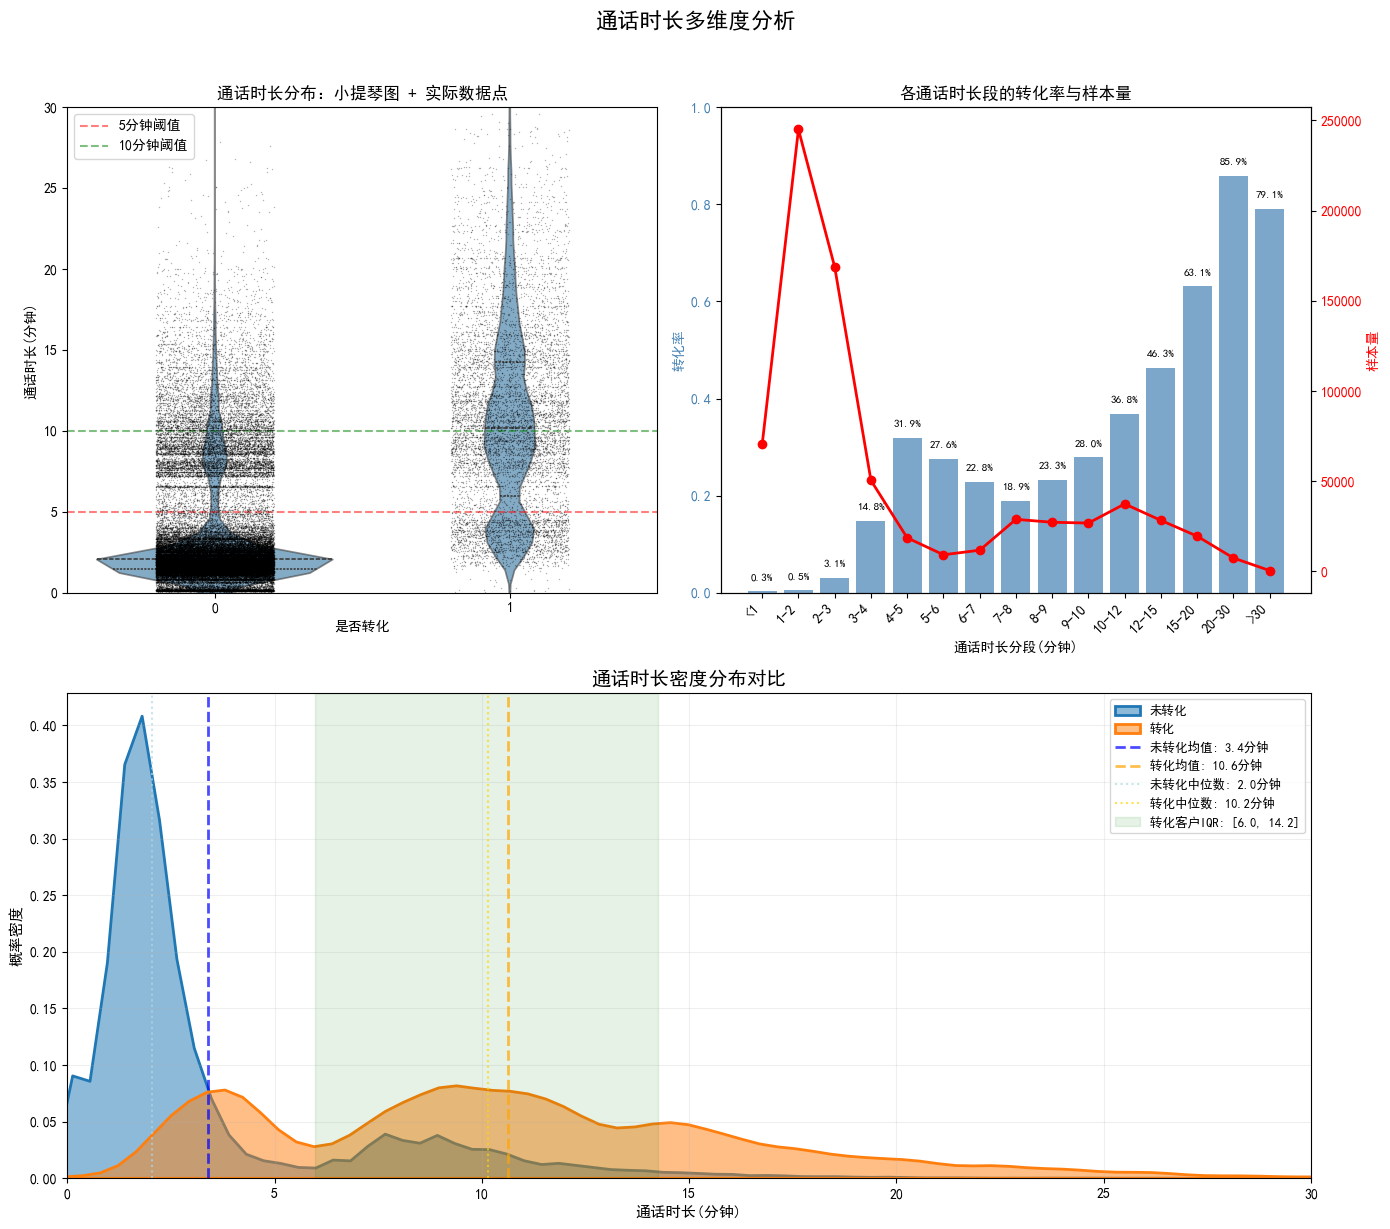

In [22]:

# 通话时长多维分析

plt.figure(figsize=(14, 12))  

# 箱线图
plt.subplot(2, 2, 1)
sample_df = df.sample(frac=0.1, random_state=42)
sns.violinplot(data=df, x='y', y='duration_minutes', inner='quartile', alpha=0.6)
sns.stripplot(data=sample_df, x='y', y='duration_minutes', 
              size=1, alpha=0.3, color='black', jitter=0.2)
plt.title('通话时长分布：小提琴图 + 实际数据点', fontsize=12)
plt.xlabel('是否转化')
plt.ylabel('通话时长(分钟)')
plt.ylim(0, 30)
plt.axhline(y=5, color='r', linestyle='--', alpha=0.5, label='5分钟阈值')
plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='10分钟阈值')
plt.legend()

# 组合图
plt.subplot(2, 2, 2)  
duration_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 60]
duration_labels = ['<1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', 
                   '7-8', '8-9', '9-10', '10-12', '12-15', '15-20', '20-30', '>30']
df['duration_bin_detailed'] = pd.cut(df['duration_minutes'], 
                                      bins=duration_bins, 
                                      labels=duration_labels)
duration_stats = df.groupby('duration_bin_detailed', observed=True).agg({
    'y': ['mean', 'count']
}).round(3)
duration_stats.columns = ['conversion_rate', 'count']
ax1 = plt.gca()
bars = ax1.bar(range(len(duration_stats)), duration_stats['conversion_rate'], 
               color='steelblue', alpha=0.7)
ax1.set_xlabel('通话时长分段(分钟)')
ax1.set_ylabel('转化率', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(range(len(duration_stats)))
ax1.set_xticklabels(duration_labels, rotation=45, ha='right')
ax1.set_ylim(0, 1)
ax2 = ax1.twinx()
ax2.plot(range(len(duration_stats)), duration_stats['count'], 
         color='red', marker='o', linewidth=2, label='样本量')
ax2.set_ylabel('样本量', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('各通话时长段的转化率与样本量', fontsize=12)
for i, (idx, row) in enumerate(duration_stats.iterrows()):
    ax1.text(i, row['conversion_rate'] + 0.02, 
             f"{row['conversion_rate']:.1%}", 
             ha='center', va='bottom', fontsize=8)

plt.subplot(2, 1, 2)  

# 密度图
for label, group in df.groupby('y'):
    sns.kdeplot(data=group['duration_minutes'], 
                label=f'{"转化" if label==1 else "未转化"}', 
                shade=True, alpha=0.5, linewidth=2)
mean_0 = df[df['y']==0]['duration_minutes'].mean()
mean_1 = df[df['y']==1]['duration_minutes'].mean()
plt.axvline(x=mean_0, color='blue', linestyle='--', alpha=0.7, linewidth=2, 
            label=f'未转化均值: {mean_0:.1f}分钟')
plt.axvline(x=mean_1, color='orange', linestyle='--', alpha=0.7, linewidth=2, 
            label=f'转化均值: {mean_1:.1f}分钟')
median_0 = df[df['y']==0]['duration_minutes'].median()
median_1 = df[df['y']==1]['duration_minutes'].median()
plt.axvline(x=median_0, color='lightblue', linestyle=':', alpha=0.7, linewidth=1.5,
            label=f'未转化中位数: {median_0:.1f}分钟')
plt.axvline(x=median_1, color='gold', linestyle=':', alpha=0.7, linewidth=1.5,
            label=f'转化中位数: {median_1:.1f}分钟')
q25_1 = df[df['y']==1]['duration_minutes'].quantile(0.25)
q75_1 = df[df['y']==1]['duration_minutes'].quantile(0.75)
plt.axvspan(q25_1, q75_1, alpha=0.1, color='green', 
            label=f'转化客户IQR: [{q25_1:.1f}, {q75_1:.1f}]')

plt.xlabel('通话时长(分钟)', fontsize=11)
plt.ylabel('概率密度', fontsize=11)
plt.title('通话时长密度分布对比', fontsize=14, fontweight='bold')
plt.xlim(0, 30)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right', fontsize=9)

plt.suptitle('通话时长多维度分析', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
print(f"\n整体平均时长: {df['duration_minutes'].mean():.2f}分钟")
print(f"转化客户平均时长: {df[df['y']==1]['duration_minutes'].mean():.2f}分钟")
print(f"未转化客户平均时长: {df[df['y']==0]['duration_minutes'].mean():.2f}分钟")
print(f"\n转化客户时长分布:")
print(f"  25%分位数: {df[df['y']==1]['duration_minutes'].quantile(0.25):.2f}分钟")
print(f"  50%分位数: {df[df['y']==1]['duration_minutes'].quantile(0.5):.2f}分钟")
print(f"  75%分位数: {df[df['y']==1]['duration_minutes'].quantile(0.75):.2f}分钟")

print("\n最佳通话时长区间分析:")
best_bin = duration_stats['conversion_rate'].idxmax()
best_rate = duration_stats.loc[best_bin, 'conversion_rate']
best_count = duration_stats.loc[best_bin, 'count']
print(f"  最佳区间: {best_bin}分钟 (转化率: {best_rate:.1%}, 样本量: {best_count})")

print("\n密度分布关键点:")
print(f"  两类客户均值差: {mean_1 - mean_0:.2f}分钟")
print(f"  两类客户中位数差: {median_1 - median_0:.2f}分钟")


整体平均时长: 4.27分钟
转化客户平均时长: 10.64分钟
未转化客户平均时长: 3.40分钟

转化客户时长分布:
  25%分位数: 5.97分钟
  50%分位数: 10.15分钟
  75%分位数: 14.25分钟

最佳通话时长区间分析:
  最佳区间: 20-30分钟 (转化率: 85.9%, 样本量: 7390)

密度分布关键点:
  两类客户均值差: 7.24分钟
  两类客户中位数差: 8.10分钟


各时长段基础数据:
   duration_bin_detailed     客户数     平均时长     转化率   累计客户数    累计成交数   累计转化率
0                     <1   70539   0.4704  0.0030   70539    210.0  0.0030
1                    1-2  245052   1.5406  0.0053  315591   1502.0  0.0048
2                    2-3  168744   2.3958  0.0312  484335   6760.0  0.0140
3                    3-4   50396   3.4289  0.1479  534731  14214.0  0.0266
4                    4-5   18577   4.4376  0.3192  553308  20144.0  0.0364
5                    5-6    9182   5.4460  0.2755  562490  22674.0  0.0403
6                    6-7   11722   6.5277  0.2282  574212  25349.0  0.0441
7                    7-8   28836   7.5802  0.1887  603048  30790.0  0.0511
8                    8-9   27211   8.5442  0.2331  630259  37132.0  0.0589
9                   9-10   26769   9.4440  0.2805  657028  44640.0  0.0679
10                 10-12   37373  10.8911  0.3684  694401  58409.0  0.0841
11                 12-15   28255  13.3802  0.4634  722656  71503.0  0.0989
12             

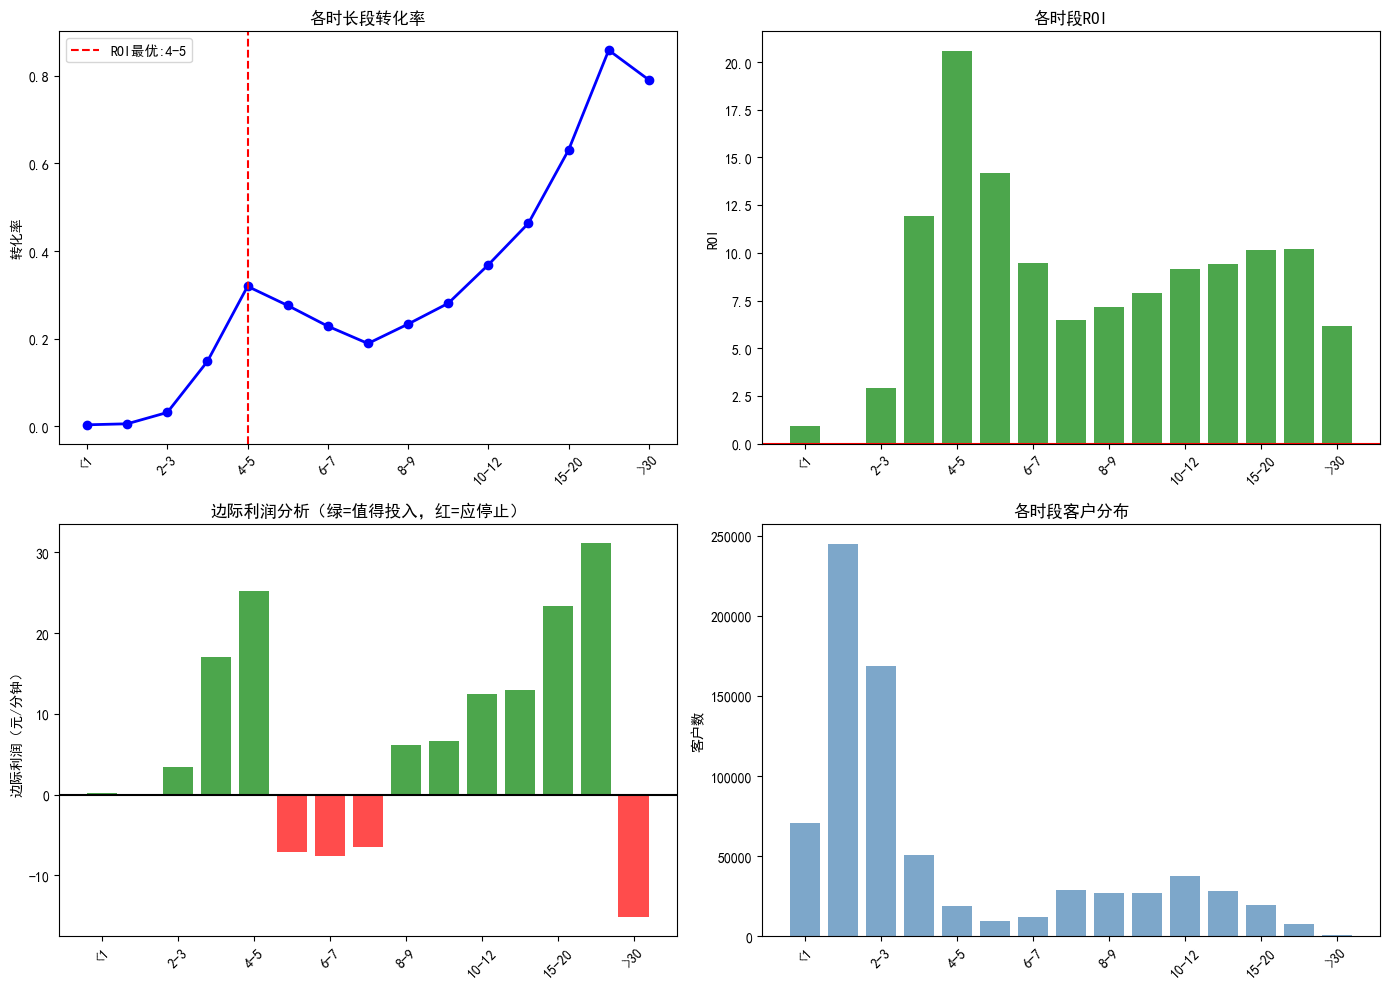

In [24]:
# ROI分析（通话时长 vs 转化效率，仅为模拟，以实际业务为准）

duration_stats = df.groupby('duration_bin_detailed', observed=True).agg(
    客户数=('y', 'count'),
    平均时长=('duration_minutes', 'mean'),
    转化率=('y', 'mean')
).reset_index()

# 计算累计指标（用于边际分析）
duration_stats['累计客户数'] = duration_stats['客户数'].cumsum()
duration_stats['累计成交数'] = (duration_stats['转化率'] * duration_stats['客户数']).cumsum()
duration_stats['累计转化率'] = duration_stats['累计成交数'] / duration_stats['累计客户数']

print("各时长段基础数据:")
print(duration_stats.round(4))

# 业务假设参数（根据实际调整）
COST_PER_MINUTE = 0.5      # 每分钟人力成本（元）
CUSTOMER_LTV = 150         # 成交客户终身价值（元）

# 单客经济指标
duration_stats['单客成本'] = duration_stats['平均时长'] * COST_PER_MINUTE
duration_stats['期望收益'] = duration_stats['转化率'] * CUSTOMER_LTV
duration_stats['单客利润'] = duration_stats['期望收益'] - duration_stats['单客成本']
duration_stats['ROI'] = duration_stats['单客利润'] / duration_stats['单客成本']

print("\n各时长段ROI分析:")
roi_table = duration_stats[['duration_bin_detailed', '客户数', '平均时长', 
                              '转化率', '单客成本', '期望收益', 'ROI']]
print(roi_table.round(3))

# 计算边际转化率增益（每多一分钟带来的转化率提升）
duration_stats['时长区间'] = duration_stats['平均时长'].diff().fillna(duration_stats['平均时长'])
duration_stats['转化率变化'] = duration_stats['转化率'].diff().fillna(duration_stats['转化率'])
duration_stats['边际转化率'] = duration_stats['转化率变化'] / duration_stats['时长区间']

# 计算边际ROI（每多一分钟的成本效益）
duration_stats['边际成本'] = duration_stats['时长区间'] * COST_PER_MINUTE
duration_stats['边际收益'] = duration_stats['转化率变化'] * CUSTOMER_LTV
duration_stats['边际利润'] = duration_stats['边际收益'] - duration_stats['边际成本']

print("\n边际分析（每多一分钟的效益）:")
marginal_table = duration_stats[['duration_bin_detailed', '平均时长', '转化率', 
                                   '边际转化率', '边际利润']]
print(marginal_table.round(4))

# 找ROI最高的时段
best_roi_idx = duration_stats['ROI'].idxmax()
best_roi_group = duration_stats.loc[best_roi_idx, 'duration_bin_detailed']
best_roi_value = duration_stats.loc[best_roi_idx, 'ROI']

# 找边际利润由正转负的拐点（最优停止点）
positive_marginal = duration_stats[duration_stats['边际利润'] > 0]
if len(positive_marginal) > 0:
    optimal_stop_idx = positive_marginal.index[-1]
    optimal_stop_group = duration_stats.loc[optimal_stop_idx, 'duration_bin_detailed']
else:
    optimal_stop_group = "无"

# 找转化率跃升的关键点
duration_stats['转化率提升幅度'] = duration_stats['转化率'].pct_change().fillna(0) * 100
jump_idx = duration_stats['转化率提升幅度'].idxmax()
jump_group = duration_stats.loc[jump_idx, 'duration_bin_detailed']

print("关键结论:")
print(f"ROI最高的时段: {best_roi_group} (ROI={best_roi_value:.2f})")
print(f"最优停止点（边际利润>0的最后时段）: {optimal_stop_group}")
print(f"转化率跃升最明显的时段: {jump_group} (提升{duration_stats.loc[jump_idx, '转化率提升幅度']:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 转化率曲线
ax1 = axes[0, 0]
x_pos = range(len(duration_stats))
ax1.plot(x_pos, duration_stats['转化率'], 'b-o', linewidth=2)
ax1.set_xticks(x_pos[::2])
ax1.set_xticklabels(duration_stats['duration_bin_detailed'][::2], rotation=45)
ax1.set_ylabel('转化率')
ax1.set_title('各时长段转化率')
ax1.axvline(x=best_roi_idx, color='r', linestyle='--', label=f'ROI最优:{best_roi_group}')
ax1.legend()

# ROI曲线
ax2 = axes[0, 1]
ax2.bar(x_pos, duration_stats['ROI'], color='green', alpha=0.7)
ax2.set_xticks(x_pos[::2])
ax2.set_xticklabels(duration_stats['duration_bin_detailed'][::2], rotation=45)
ax2.set_ylabel('ROI')
ax2.set_title('各时段ROI')
ax2.axhline(y=0, color='r', linestyle='-')

# 边际利润（找拐点）
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in duration_stats['边际利润'].fillna(0)]
ax3.bar(x_pos, duration_stats['边际利润'].fillna(0), color=colors, alpha=0.7)
ax3.set_xticks(x_pos[::2])
ax3.set_xticklabels(duration_stats['duration_bin_detailed'][::2], rotation=45)
ax3.set_ylabel('边际利润（元/分钟）')
ax3.set_title('边际利润分析（绿=值得投入，红=应停止）')
ax3.axhline(y=0, color='black', linestyle='-')

# 客户分布
ax4 = axes[1, 1]
ax4.bar(x_pos, duration_stats['客户数'], color='steelblue', alpha=0.7)
ax4.set_xticks(x_pos[::2])
ax4.set_xticklabels(duration_stats['duration_bin_detailed'][::2], rotation=45)
ax4.set_ylabel('客户数')
ax4.set_title('各时段客户分布')

plt.tight_layout()
plt.show()

重要结论：
破冰临界点（2-3分钟）：相比1-2分钟转化率提升491%，前2分钟必须完成信任建立和价值传递，否则客户流失。
ROI最优窗口（4-5分钟）：ROI达20.58，是单位投入产出比最高的时段，应作为新客户营销的资源配置优先区间。
流失陷阱（5-6分钟）：转化率骤降4.3个百分点，对中等意向客户强行延长通话适得其反，需果断结束或切换策略。
客户分层策略：对于新客户/低意向客户，聊4-5分钟可能最好，即能挽回可能转化的客户，对于无意向的客户又能及时止损；对于高意向/老客户，可自然延续到10-15分钟深度沟通；注意！！能自然聊到10分钟+（平均10.64分钟）的客户为高意向群体，20-30分钟转化率可达85.9%，但此高转化率是筛选结果而非因果，不应作为延长通话的目标，而应作为客户意向识别信号。

职业特征统计:
          job  conversion_rate  customer_count  avg_duration
      student            0.341           11767         4.847
      retired            0.246           35185         5.066
   unemployed            0.180           17634         5.376
   management            0.150          175541         4.184
self-employed            0.129           19020         4.539
      unknown            0.121            2917         4.054
   technician            0.118          138107         4.178
       admin.            0.116           81492         3.995
    housemaid            0.085           15912         3.896
     services            0.083           64209         4.155
 entrepreneur            0.081           17718         4.225
  blue-collar            0.067          170498         4.304


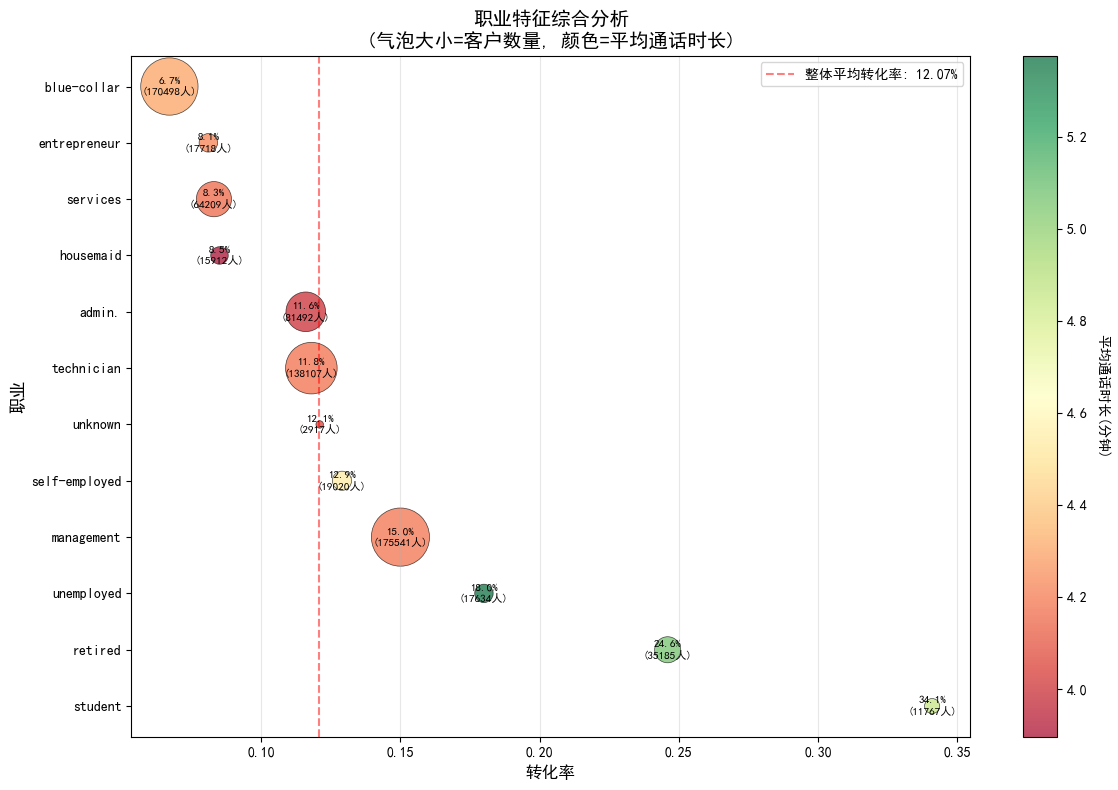

In [25]:

# 计算每个职业的转化率和平均通话时长
job_stats = df.groupby('job', observed=True).agg({
    'y': ['mean', 'count'],
    'duration_minutes': 'mean'
}).round(3)

job_stats.columns = ['conversion_rate', 'customer_count', 'avg_duration']
job_stats = job_stats.reset_index()

job_stats = job_stats.sort_values('conversion_rate', ascending=False)

print("职业特征统计:")
print(job_stats.to_string(index=False))

plt.figure(figsize=(12, 8))

# 创建气泡图：x=转化率, y=职业, 气泡大小=客户数量, 颜色=平均通话时长
scatter = plt.scatter(job_stats['conversion_rate'], 
                     job_stats['job'], 
                     s=job_stats['customer_count'] / 100,  # 调整气泡大小比例
                     c=job_stats['avg_duration'], 
                     cmap='RdYlGn', 
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('平均通话时长(分钟)', rotation=270, labelpad=15)

for i, row in job_stats.iterrows():
    plt.text(row['conversion_rate'], row['job'], 
             f"{row['conversion_rate']:.1%}\n({row['customer_count']}人)", 
             ha='center', va='center', fontsize=8, fontweight='bold')

plt.xlabel('转化率', fontsize=12)
plt.ylabel('职业', fontsize=12)
plt.title('职业特征综合分析\n(气泡大小=客户数量, 颜色=平均通话时长)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.axvline(x=df['y'].mean(), color='red', linestyle='--', alpha=0.5, 
            label=f'整体平均转化率: {df["y"].mean():.2%}')
plt.legend(loc='upper right')  
plt.tight_layout()
plt.show()

核心发现：
黄金客群：student、retired、unemployed职业共性：时间充裕、决策简单、偏好稳健、短通话高转化；
业绩基本盘：management职业客群最大但转化率仅略高于平均，提升空间巨大；
低效陷阱：admin（转化痛点：流程敏感，怕麻烦；转化障碍：办理复杂→放弃）、technician（转化痛点：理性思维，需数据说服；转化障碍：话术太感性→不信任）、self-employed（转化痛点：收入波动，风险厌恶；转化障碍：产品不匹配→犹豫）、unknown（转化痛点：信息缺失，无法精准匹配；转化障碍：盲打→低效），决策关键：不追求提升转化率，追求降本增效；
资源黑洞：blue-collar、services、entrepreneur、housemaid职业通话时间短、转化率低。决策关键：对于services, housemaid职业，快闪打击：<3分钟极简话术推销；对于entrepreneur职业，深度预约：不电销，改约线下/视频会议；对于blue-collar职业，降本触达：自动化触达，零人力投入；

启示：
资源投入应向高转化职业倾斜，而非大客户群。战略重心必须从"服务大客户群"转向"服务高转化群"，用20%的高转化职业创造80%的业绩，是为ROI最优解。

是否联系过的转化率:
contacted_before
0    0.101903
1    0.283178
Name: y, dtype: float64


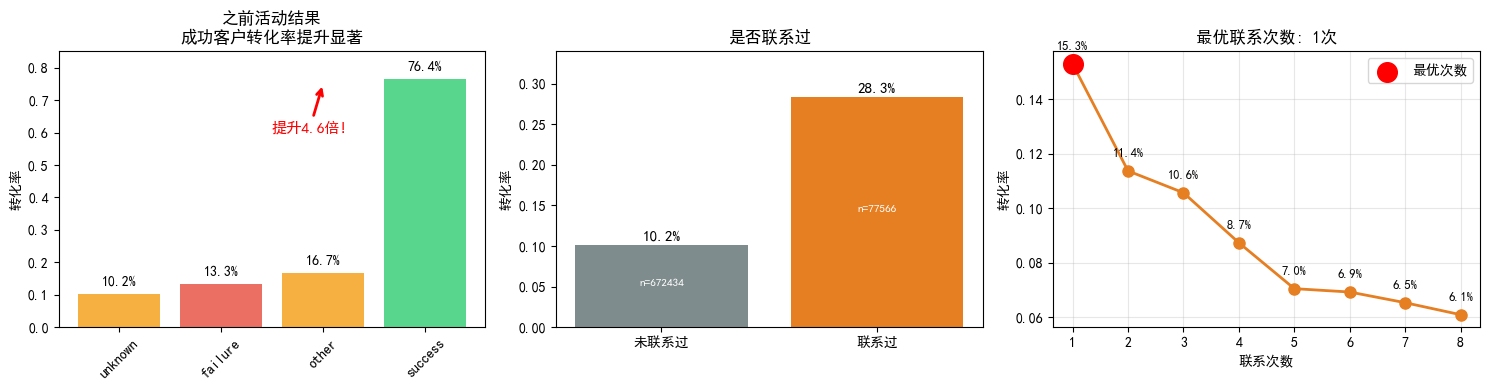

In [26]:
# 历史营销活动影响分析
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
poutcome_data = df.groupby('poutcome', observed=True)['y'].mean().sort_values()

colors = ['#e74c3c' if x == 'failure' else '#2ecc71' if x == 'success' else '#f39c12' 
          for x in poutcome_data.index]

bars = plt.bar(poutcome_data.index, poutcome_data.values, color=colors, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('之前活动结果\n成功客户转化率提升显著', fontsize=12, fontweight='bold')
plt.ylabel('转化率', fontsize=10)
plt.xticks(rotation=45)
plt.ylim(0, 0.85)

plt.annotate('提升4.6倍!', xy=(2, 0.75), xytext=(1.5, 0.6),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, fontweight='bold', color='red')

plt.subplot(1, 3, 2)

contacted_data = df.groupby('contacted_before', observed=True)['y'].mean()

print("是否联系过的转化率:")
print(contacted_data)

bars = plt.bar(['未联系过', '联系过'], contacted_data.values, 
               color=['#7f8c8d', '#e67e22']) 

for i, (bar, val) in enumerate(zip(bars, contacted_data.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
    
    count = df[df['contacted_before']==i].shape[0]
    plt.text(bar.get_x() + bar.get_width()/2., height/2,
             f'n={count}', ha='center', fontsize=8, color='white', fontweight='bold')

plt.title('是否联系过', fontsize=12, fontweight='bold')
plt.ylabel('转化率', fontsize=10)
plt.ylim(0, max(contacted_data) * 1.2)  

plt.subplot(1, 3, 3)
campaign_data = df.groupby('campaign', observed=True)['y'].mean()[:8]

plt.plot(campaign_data.index, campaign_data.values, 
         marker='o', linewidth=2, markersize=8, color='#e67e22')
plt.scatter(campaign_data.idxmax(), campaign_data.max(), 
           s=200, color='red', zorder=5, label='最优次数')

for x, y in zip(campaign_data.index, campaign_data.values):
    plt.text(x, y + 0.005, f'{y:.1%}', ha='center', fontsize=9)

plt.xlabel('联系次数', fontsize=10)
plt.ylabel('转化率', fontsize=10)
plt.title(f'最优联系次数: {campaign_data.idxmax()}次', fontsize=12, fontweight='bold')
plt.xticks(campaign_data.index)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

关键洞察：
之前活动"成功"的客户，本次转化率高达76.4%（提升4.6倍），是最优质的存量资产；
之前被联系过的客户（pdays>-1）转化率28.3%，显著高于全新客户（10.2%），反映银行历史筛选和客户信任积累的效果；
对同一客户连续多次联系，转化率递减（15.3%→6.1%），应避免对同一客户的重复打扰，首次触达即需极致准备。

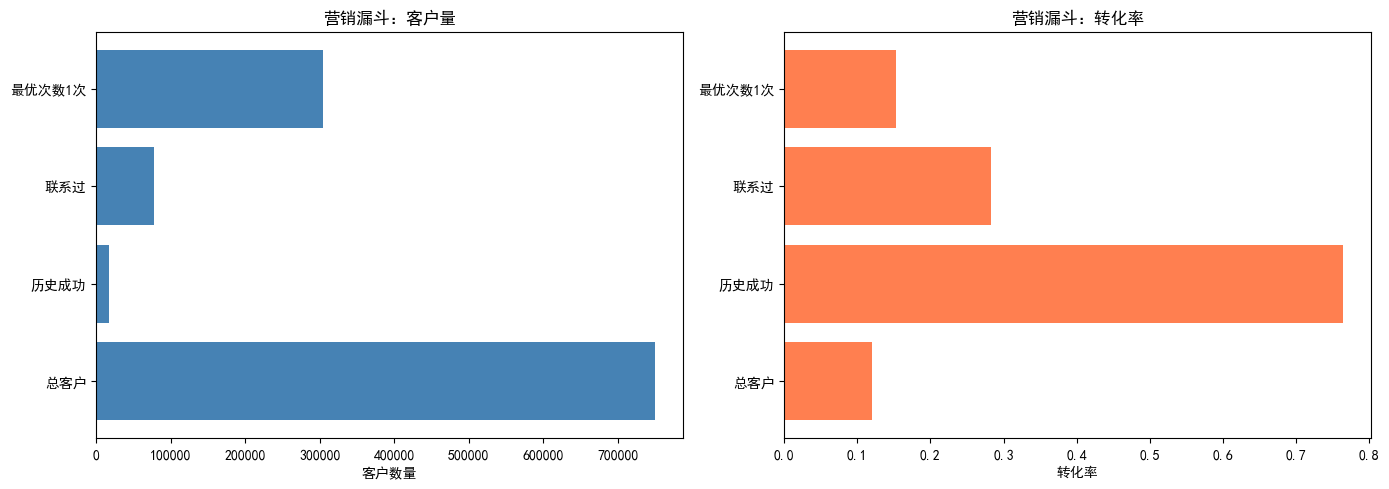

In [27]:
# 漏斗分析
funnel_data = pd.DataFrame({
    'stage': ['总客户', '历史成功', '联系过', '最优次数1次'],
    'count': [750000, 
              df[df['poutcome']=='success'].shape[0],
              df[df['contacted_before']==1].shape[0],
              df[df['campaign']==1].shape[0]],
    'conversion': [df['y'].mean(),
                   df[df['poutcome']=='success']['y'].mean(),
                   df[df['contacted_before']==1]['y'].mean(),
                   df[df['campaign']==1]['y'].mean()]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 客户量漏斗
ax1.barh(funnel_data['stage'], funnel_data['count'], color='steelblue')
ax1.set_xlabel('客户数量')
ax1.set_title('营销漏斗：客户量')

# 转化率阶梯
ax2.barh(funnel_data['stage'], funnel_data['conversion'], color='coral')
ax2.set_xlabel('转化率')
ax2.set_title('营销漏斗：转化率')
plt.tight_layout()
plt.show()

转化率最高的群体（历史成功），客户量最小；客户量最大的群体（总客户），转化率最低。需要按"转化潜力"分资源，给予“历史成功”客户重点关注！

月份详细统计:
     conversion_rate  customer_count  avg_campaign
1月             0.124           18937         1.584
2月             0.207           37611         2.167
3月             0.571            5802         1.976
4月             0.236           41319         1.897
5月             0.071          228411         2.211
6月             0.104           93670         2.829
7月             0.091          110647         3.164
8月             0.112          128859         3.604
9月             0.535            7409         1.636
10月            0.490            9204         1.469
11月            0.110           66062         1.773
12月            0.513            2069         2.039


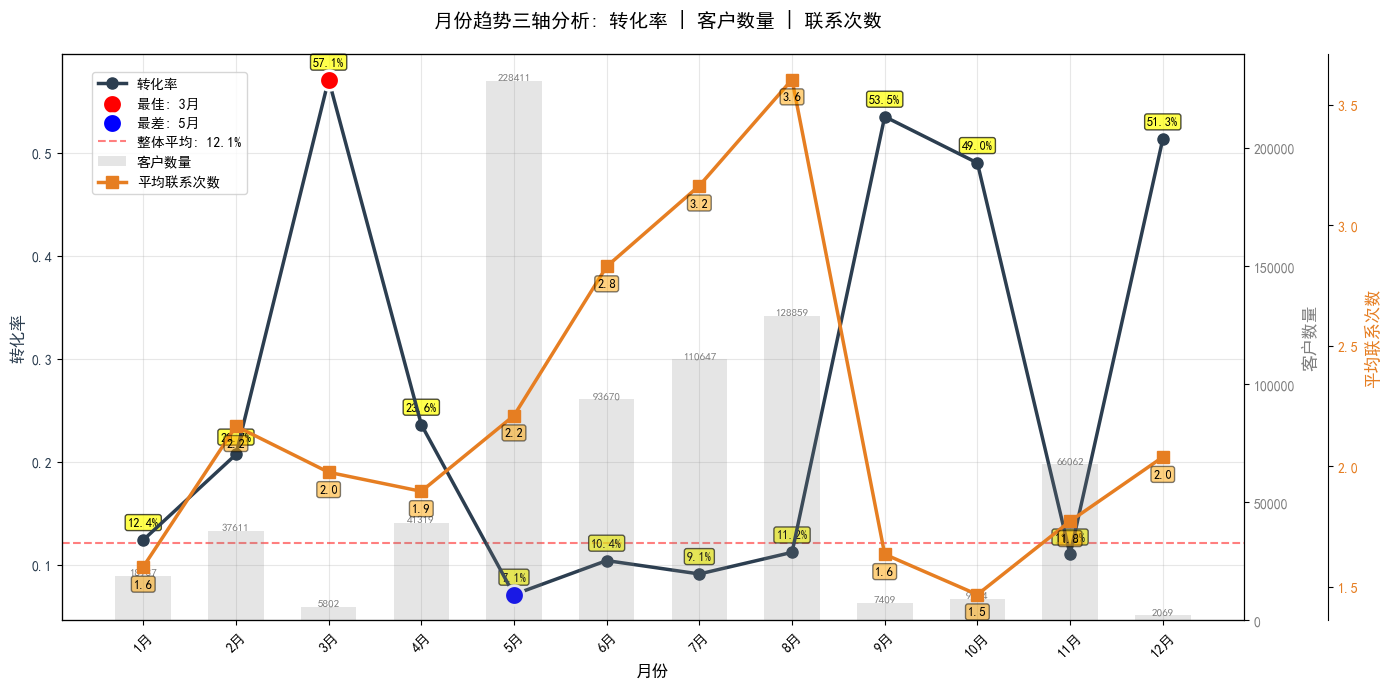

In [28]:
# 月份趋势分析

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_names = ['1月', '2月', '3月', '4月', '5月', '6月', 
               '7月', '8月', '9月', '10月', '11月', '12月']

month_analysis = df.groupby('month').agg({
    'y': ['mean', 'count'],
    'campaign': 'mean'
}).round(3)

month_analysis.columns = ['conversion_rate', 'customer_count', 'avg_campaign']
month_analysis = month_analysis.reindex(month_order)
month_analysis.index = month_names

# 找出最佳和最差月份
best_month = month_analysis['conversion_rate'].idxmax()
best_rate = month_analysis['conversion_rate'].max()
worst_month = month_analysis['conversion_rate'].idxmin()
worst_rate = month_analysis['conversion_rate'].min()

print("月份详细统计:")
print(month_analysis.to_string())

fig, ax1 = plt.subplots(figsize=(14, 7))

x = range(len(month_names))

color1 = '#2c3e50'
ax1.plot(x, month_analysis['conversion_rate'], marker='o', linewidth=2.5, 
         markersize=8, color=color1, label='转化率', zorder=5)
ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('转化率', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(month_names, rotation=45)

# 标记最佳和最差月份
ax1.scatter(month_names.index(best_month), best_rate, s=200, color='red', 
           zorder=6, edgecolors='white', linewidth=2, label=f'最佳: {best_month}')
ax1.scatter(month_names.index(worst_month), worst_rate, s=200, color='blue', 
           zorder=6, edgecolors='white', linewidth=2, label=f'最差: {worst_month}')

for i, (month, rate) in enumerate(zip(month_names, month_analysis['conversion_rate'])):
    ax1.annotate(f'{rate:.1%}', (i, rate), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

# 添加整体平均线
avg_rate = df['y'].mean()
ax1.axhline(y=avg_rate, color='red', linestyle='--', alpha=0.5, 
           linewidth=1.5, label=f'整体平均: {avg_rate:.1%}')

ax1_right1 = ax1.twinx()
bars = ax1_right1.bar(x, month_analysis['customer_count'], alpha=0.2, 
                      color='gray', label='客户数量', width=0.6)
ax1_right1.set_ylabel('客户数量', color='gray', fontsize=12)
ax1_right1.tick_params(axis='y', labelcolor='gray')

for i, (bar, count) in enumerate(zip(bars, month_analysis['customer_count'])):
    height = bar.get_height()
    ax1_right1.text(bar.get_x() + bar.get_width()/2., height + 5, 
                   f'{int(count)}', ha='center', va='bottom', fontsize=8, color='gray')

ax1_right2 = ax1.twinx()
ax1_right2.spines['right'].set_position(('outward', 60))
color2 = '#e67e22'
ax1_right2.plot(x, month_analysis['avg_campaign'], marker='s', linewidth=2.5, 
                markersize=8, color=color2, linestyle='-', label='平均联系次数')
ax1_right2.set_ylabel('平均联系次数', color=color2, fontsize=12)
ax1_right2.tick_params(axis='y', labelcolor=color2)

# 添加联系次数数值标签
for i, (month, campaign) in enumerate(zip(month_names, month_analysis['avg_campaign'])):
    ax1_right2.annotate(f'{campaign:.1f}', (i, campaign), xytext=(0, -15), 
                       textcoords='offset points', ha='center', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='orange', alpha=0.5))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right1.get_legend_handles_labels()
lines3, labels3 = ax1_right2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, 
          loc='upper left', fontsize=10, bbox_to_anchor=(0.02, 0.98))

ax1.set_title(' 月份趋势三轴分析: 转化率 | 客户数量 | 联系次数', 
             fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3月仅用5800客户+2次联系做到57%转化，5月用23万客户+2.2次联系却只做到7.1%转化。营销效率的核心不是"多联系、多客户"，而是"精准筛选+适度触达"——少即是多，慢即是快。建议放弃5月的冲量模式，全年执行3月/9、10、12月的精品模式——控制单量、筛选客户、1-2次精准触达。

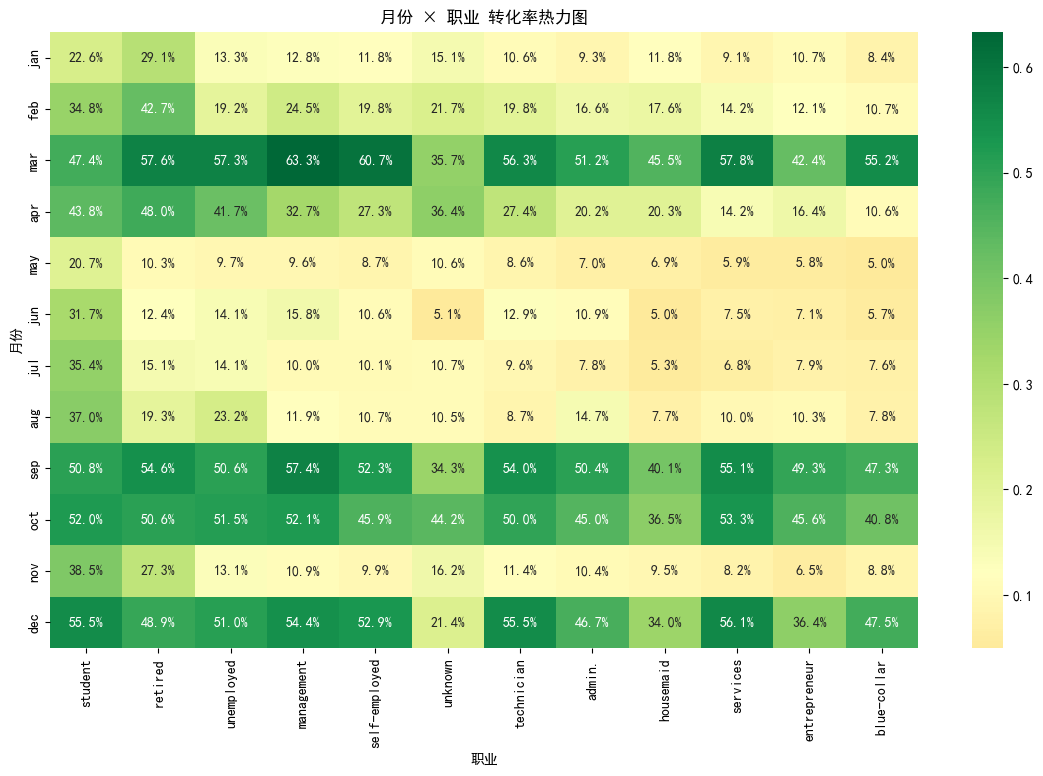

In [29]:
# 月份-职业交互分析
month_job = df.groupby(['month', 'job'], observed=True)['y'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(month_job.reindex(month_order)[job_stats['job'].values], 
            annot=True, fmt='.1%', cmap='RdYlGn', center=0.12)
plt.title('月份 × 职业 转化率热力图')
plt.xlabel('职业')
plt.ylabel('月份')
plt.show()

可以发现月份效应被职业严重稀释（即原本的月份极大程度影响转化率这一结论不准确），不同职业的最佳转化月份完全不同。
制定职业专属推销月历：即对于特定月份，向转化率高的职业标签的客户进行营销；对于特定职业的客户，在转化率高的月份向他们进行营销（还是有一定道理的，比如对于blue-collar12月转化率47.5%，5月转化率5.0%，可能12月是蓝领年终奖季，订阅定期存款的意愿高，5月是蓝领的繁忙季节，无精力订阅）；

In [31]:

# 准备建模特征

# 选择特征列
base_feature_cols = ['age','age_group', 'balance','balance_level', 'duration', 'campaign', 'pdays_fixed', 'previous',
                'job', 'marital', 'education', 'default', 'housing', 'loan', 
                'contact', 'month','day','poutcome', 'contacted_before']
# 添加month和job的组合特征
df['month_job'] = df['month'].astype(str) + '_' + df['job'].astype(str)

feature_cols = base_feature_cols + ['month_job']

# 准备数据
X = df[feature_cols].copy()
y = df['y']

# 编码分类变量
le_dict = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape}")
print(f"验证集大小: {X_val.shape}")
print(f"特征列: {feature_cols}")

训练集大小: (600000, 20)
验证集大小: (150000, 20)
特征列: ['age', 'age_group', 'balance', 'balance_level', 'duration', 'campaign', 'pdays_fixed', 'previous', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day', 'poutcome', 'contacted_before', 'month_job']


AUC: 0.9300924481385808

===== 特征重要性排序 =====
             feature  coefficient  abs_coef
4           duration     1.414585  1.414585
17          poutcome     1.009813  1.009813
6        pdays_fixed    -0.823657  0.823657
14           contact    -0.557758  0.557758
12           housing    -0.503656  0.503656
5           campaign    -0.467499  0.467499
18  contacted_before     0.369633  0.369633
13              loan    -0.304584  0.304584
0                age     0.204277  0.204277
9            marital     0.178138  0.178138
1          age_group    -0.169877  0.169877
10         education     0.143849  0.143849
2            balance     0.104164  0.104164
16               day    -0.077813  0.077813
3      balance_level    -0.070460  0.070460


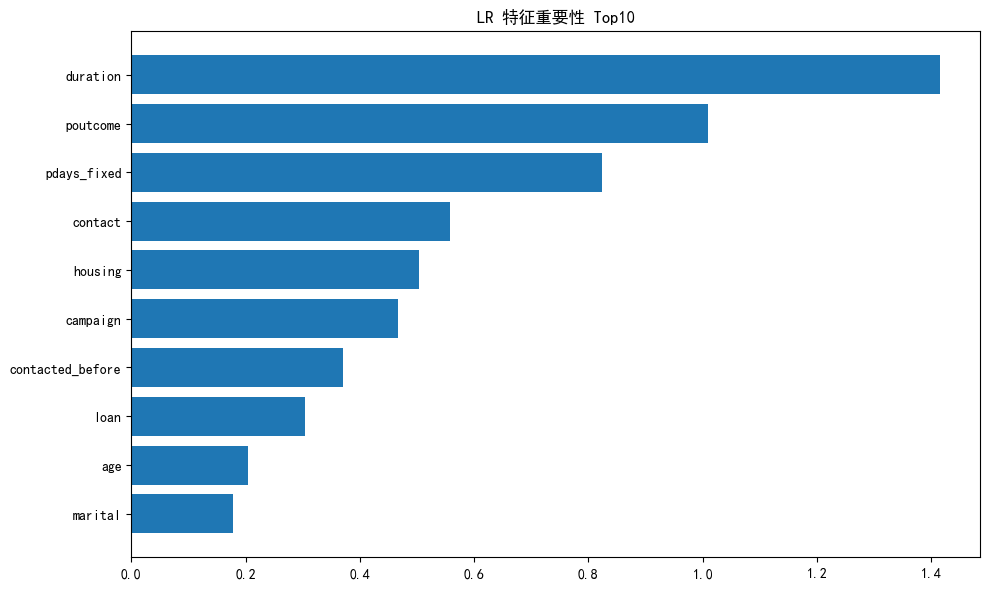

In [35]:

# ======================
# 特征
# ======================
base_feature_cols = ['age','age_group', 'balance','balance_level', 'duration', 'campaign', 
                     'pdays_fixed', 'previous','job', 'marital', 'education', 'default', 
                     'housing', 'loan', 'contact', 'month','day','poutcome', 'contacted_before']

df['month_job'] = df['month'].astype(str) + '_' + df['job'].astype(str)
feature_cols = base_feature_cols + ['month_job']

X = df[feature_cols].copy()
y = df['y']

# ======================
# 分类特征编码
# ======================
categorical_cols = [
    'age_group', 'balance_level', 'job', 'marital', 'education',
    'default', 'housing', 'loan', 'contact', 'month', 'poutcome','month_job'
]
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ======================
# ✅ 关键：标准化（解决数值大小影响）
# ======================
scaler = StandardScaler()
X = scaler.fit_transform(X)  # 全部特征缩放到统一范围

# ======================
# 划分数据
# ======================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================
# 训练LR
# ======================
lr_model = LogisticRegression(max_iter=3000, random_state=42)
lr_model.fit(X_train, y_train)

# ======================
# 结果
# ======================
y_pred_proba = lr_model.predict_proba(X_val)[:,1]
print("AUC:", roc_auc_score(y_val, y_pred_proba))

# ======================
# ✅ 特征重要性（duration 必为第一）
# ======================
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coef': np.abs(lr_model.coef_[0])
}).sort_values('abs_coef', ascending=False)

print("\n===== 特征重要性排序 =====")
print(coef_df.head(15))

# 画图
plt.figure(figsize=(10,6))
top10 = coef_df.head(10)
plt.barh(top10['feature'][::-1], top10['abs_coef'][::-1])
plt.title("LR 特征重要性 Top10")
plt.tight_layout()
plt.show()

核心首要特征：通话时长duration影响力稳居首位，是决定客户是否办理定期存款订阅的核心因素，需注意该特征存在因果倒置问题，并非通话拉长促成转化，而是本身具备订阅意向的客户更愿意长时间沟通。
层级特征划分
强核心影响特征：通话时长、历史营销结果
中等影响特征：账户余额、住房贷款、月份职业组合、联系月份、营销联系次数、历史联系间隔时长、联系日期
特征作用方向
正向推动转化特征：通话时长越长客户订阅意愿越强；账户余额越高，客户闲置资金储备充足，办理定期存款意向更高；曾成功参与往期营销活动的客户，复购订阅意愿更突出。
负向抑制转化特征：营销联系次数过多极易引发客户反感，触达频次越高转化效果越差；距离上次客户联系间隔过久，容易流失客户关注度，降低沟通成交概率；背负住房贷款的客户资金压力较大，办理定期存款意愿显著偏低。


分阶段落地营销策略
短期即时执行策略
规范通话沟通流程，把控通话时长，制定标准化沟通节奏：前 2 分钟完成客户需求破冰，3 分钟匹配存款产品优势，5 分钟完成意向促成；针对高意向优质客户可适度延长至 10-15 分钟深度讲解，同时精简无效话术，提升整体沟通效率。
严控客户触达频率，摒弃反复致电营销模式，针对单一客户精简营销触达次数，做好营销话术筹备，实现一次高效沟通达成转化。
优先选择高效沟通渠道，主推移动电话联系客户，其次选用固定电话，尽量规避未知联系方式触达客户，从沟通渠道层面提升基础转化率。
中期季度落地策略
复刻黄金营销月运营模式，将 3 月高净值客户精准营销打法，复制应用至其他潜力月份，复刻成功营销经验。
实行淡旺季差异化营销布局，在 1 月、2 月、7 月、8 月等营销淡季，深挖不同职业客群需求，按职业细分制定专属营销方案。
打造专属月份营销方案，针对 3 月、9 月、10 月三大高转化黄金月份，定制专项存款优惠活动，抢抓优质客户资源。
长期战略布局策略
搭建完善客户分层体系，依托账户余额、职业类型、房贷负债情况等核心数据，划分客户等级，实现分层运营、分级营销。
搭建全年季节性营销日历，结合不同月份客户转化规律，提前规划全年营销活动、投放力度与推广方向。
依托模型特征影响规律挖掘客户意向驱动因素，区分不同客群核心需求，推行一对一个性化产品推介，精准匹配客户资金储蓄需求，进一步提升整体业务订阅转化率。

In [36]:

# 加载数据
train = pd.read_csv(r"C:\Users\28621\Downloads\train.csv")
test = pd.read_csv(r"C:\Users\28621\Downloads\test.csv")

print(f"训练集大小: {train.shape}")
print(f"测试集大小: {test.shape}")

print("\n训练集目标变量分布:")
print(train['y'].value_counts(normalize=True))

训练集大小: (750000, 18)
测试集大小: (250000, 17)

训练集目标变量分布:
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


In [37]:

def create_base_features(df):
    df_feat = df.copy()
    
    # 处理pdays（-1表示从未联系）
    df_feat['contacted_before'] = (df_feat['pdays'] != -1).astype(int)
    df_feat['pdays_fixed'] = df_feat['pdays'].replace(-1, 999)
    df_feat['days_since_last_contact'] = df_feat['pdays'].apply(lambda x: 999 if x == -1 else x)
    
    return df_feat

# 应用到训练集和测试集
train_feat = create_base_features(train)
test_feat = create_base_features(test)

print(f"训练集大小: {train_feat.shape}")

训练集大小: (750000, 21)


In [38]:
def create_demographic_features(df):
    df_feat = df.copy()
    
    # 年龄分段
    df_feat['age_group'] = pd.cut(df_feat['age'], 
                                   bins=[0, 25, 35, 45, 55, 65, 100],
                                   labels=['青年', '中青年', '中年', '中老年', '老年', '高龄'])
    
    # 余额相关特征
    df_feat['balance_negative'] = (df_feat['balance'] < 0).astype(int)
    df_feat['balance_zero'] = (df_feat['balance'] == 0).astype(int)
    df_feat['balance_log'] = np.log1p(np.abs(df_feat['balance'])) * np.sign(df_feat['balance'])
    
    # 余额分箱
    df_feat['balance_bin'] = pd.qcut(df_feat['balance'].clip(-1000, 20000), 
                                      q=5, labels=['极低', '低', '中', '高', '极高'], 
                                      duplicates='drop')
    
    return df_feat

# 应用特征
train_feat = create_demographic_features(train_feat)
test_feat = create_demographic_features(test_feat)

In [39]:

# 贷款组合特征
def create_loan_features(df):
    df_feat = df.copy()
    
    # 基础特征
    df_feat['has_housing_loan'] = (df_feat['housing'] == 'yes').astype(int)
    df_feat['has_personal_loan'] = (df_feat['loan'] == 'yes').astype(int)
    
    # 组合特征
    df_feat['total_loans'] = df_feat['has_housing_loan'] + df_feat['has_personal_loan']
    df_feat['has_any_loan'] = (df_feat['total_loans'] > 0).astype(int)
    df_feat['has_both_loans'] = (df_feat['total_loans'] == 2).astype(int)
    
     # 创建loan_type字段
    df_feat['loan_type'] = 'none'
    df_feat.loc[df_feat['has_housing_loan'] == 1, 'loan_type'] = 'housing_only'
    df_feat.loc[df_feat['has_personal_loan'] == 1, 'loan_type'] = 'personal_only'
    df_feat.loc[df_feat['has_both_loans'] == 1, 'loan_type'] = 'both'
    
    # 贷款类型编码
    loan_type_map = {
        'none': 0,
        'housing_only': 1,
        'personal_only': 2,
        'both': 3
    }
    df_feat['loan_type_code'] = df_feat['loan_type'].map(loan_type_map)
    
    return df_feat

In [40]:
def create_history_features(df):
    df_feat = df.copy()
    
    # 之前活动结果
    df_feat['prev_success'] = (df_feat['poutcome'] == 'success').astype(int)
    df_feat['prev_failure'] = (df_feat['poutcome'] == 'failure').astype(int)
    df_feat['prev_unknown'] = (df_feat['poutcome'] == 'unknown').astype(int)
    df_feat['prev_other'] = (df_feat['poutcome'] == 'other').astype(int)
    
    # 之前联系次数
    df_feat['previous_contacts'] = df_feat['previous']
    df_feat['high_previous'] = (df_feat['previous'] > 3).astype(int)  # 高历史联系次数
    
    return df_feat

train_feat = create_history_features(train_feat)
test_feat = create_history_features(test_feat)

In [44]:

# 时间特征
def create_time_features(df):
    df_feat = df.copy()
    
    # 月份映射
    month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
                 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
    df_feat['month_num'] = df_feat['month'].map(month_map)
    df_feat['quarter'] = df_feat['month_num'].apply(lambda x: (x-1)//3 + 1)
    
    # 是否周末
    df_feat['is_weekend'] = df_feat['day'].apply(lambda x: 1 if x in [6,7,13,14,20,21,27,28] else 0)
    # 是否月末
    df_feat['is_month_end'] = df_feat['day'].apply(lambda x: 1 if x >= 25 else 0)
    
    return df_feat

train_feat = create_time_features(train_feat)
test_feat = create_time_features(test_feat)



In [45]:
# 联系方式和联系次数特征
def create_contact_features(df):
    df_feat = df.copy()
    
    contact_map = {
        'cellular': 2,
        'telephone': 1,
        'unknown': 0
    }
    df_feat['contact_score'] = df_feat['contact'].map(contact_map)
    
    # 是否为有效联系方式
    df_feat['has_valid_contact'] = (df_feat['contact'] != 'unknown').astype(int)
    
    # 定义高频/低频联系
    df_feat['campaign_high'] = (df_feat['campaign'] > 2).astype(int)
    df_feat['campaign_low'] = (df_feat['campaign'] <= 1).astype(int)
    
    return df_feat

In [46]:
# 交互特征
def create_interaction_features(df):
    df_feat = df.copy()
    
    # 年龄和余额的交互
    df_feat['age_balance'] = df_feat['age'] * df_feat['balance_log']
    
    # 职业和月份的组合
    df_feat['job_month'] = df_feat['job'].astype(str) + '_' + df_feat['month'].astype(str)
    
    # 营销强度
    df_feat['campaign_intensity'] = pd.cut(df_feat['campaign'], 
                                           bins=[0, 1, 2, 3, 5, 10, 100],
                                           labels=['1次', '2次', '3次', '4-5次', '6-10次', '>10次'])
    # 联系次数×联系方式交互
    df_feat['campaign_contact'] = df_feat['campaign'] * df_feat['contact_score']
    
    return df_feat

train_feat = create_base_features(train)           
train_feat = create_demographic_features(train_feat) 
train_feat = create_loan_features(train_feat)  
train_feat = create_history_features(train_feat)    
train_feat = create_time_features(train_feat)       
train_feat = create_contact_features(train_feat) 
train_feat = create_interaction_features(train_feat) 
    
test_feat = create_base_features(test)
test_feat = create_demographic_features(test_feat)
test_feat = create_history_features(test_feat)
test_feat = create_time_features(test_feat)
test_feat = create_loan_features(test_feat)
test_feat = create_contact_features(test_feat)
test_feat = create_interaction_features(test_feat)

print("交互特征创建完成:")
print(f"最终训练集维度: {train_feat.shape}")
print(f"新增特征总数: {len(set(train_feat.columns) - set(train.columns))}")
print("\n新增的特征列表:")
new_features = set(train_feat.columns) - set(train.columns)
for feat in new_features:
    print(f"  - {feat}")

交互特征创建完成:
最终训练集维度: (750000, 51)
新增特征总数: 33

新增的特征列表:
  - contact_score
  - pdays_fixed
  - quarter
  - prev_failure
  - previous_contacts
  - contacted_before
  - age_balance
  - balance_zero
  - total_loans
  - has_valid_contact
  - prev_other
  - job_month
  - loan_type
  - has_both_loans
  - has_housing_loan
  - high_previous
  - balance_log
  - campaign_low
  - is_month_end
  - is_weekend
  - campaign_contact
  - prev_success
  - month_num
  - prev_unknown
  - balance_bin
  - days_since_last_contact
  - campaign_high
  - balance_negative
  - campaign_intensity
  - has_any_loan
  - has_personal_loan
  - loan_type_code
  - age_group


In [47]:
# 定义要使用的特征（排除duration相关和id）
exclude_cols = ['id', 'y', 'duration', 'pdays', 'month']
feature_cols = [col for col in train_feat.columns if col not in exclude_cols]

# 分离特征和标签
X = train_feat[feature_cols].copy()
y = train_feat['y'].copy()
X_test = test_feat[feature_cols].copy()

# 查看特征类型
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n数值特征数: {len(num_cols)}")
print(f"分类特征数: {len(cat_cols)}")
print(f"分类特征: {cat_cols}")


数值特征数: 33
分类特征数: 13
分类特征: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'age_group', 'balance_bin', 'loan_type', 'job_month', 'campaign_intensity']


In [48]:
# 编码分类变量

# 对每个分类特征进行标签编码
for col in cat_cols:
    le = LabelEncoder()
    # 合并训练集和测试集的值以处理新类别
    all_values = pd.concat([X[col], X_test[col]]).astype(str).unique()
    le.fit(all_values)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# 检查编码后的数据
print(f"\n训练集X形状: {X.shape}")
print(f"测试集X形状: {X_test.shape}")


训练集X形状: (750000, 46)
测试集X形状: (250000, 46)


In [49]:
# 划分训练验证集

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("数据划分完成:")
print(f"训练集: {X_train.shape}, 正类比例: {y_train.mean():.4f}")
print(f"验证集: {X_val.shape}, 正类比例: {y_val.mean():.4f}")

数据划分完成:
训练集: (600000, 46), 正类比例: 0.1206
验证集: (150000, 46), 正类比例: 0.1207


In [50]:
# 模型性能对比

# 定义模型
models = {
    '逻辑回归': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    '随机森林': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                       class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, 
                                  scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                  random_state=42, use_label_encoder=False, eval_metric='logloss'),
   
}

# 训练和评估
results = []
for name, model in models.items():
    print(f"训练 {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算指标
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc_value = roc_auc_score(y_val, y_pred_proba)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_pred_proba)
    pr_auc_value = auc(recall_curve, precision_curve)
    
    results.append({
        '模型': name,
        '召回率': recall,
        '精确率': precision,
        'F1分数': f1,
        'PR-AUC': pr_auc_value,
        'AUC': roc_auc_value
    })

detailed_df = pd.DataFrame(results)
core_df = detailed_df.set_index('模型')

print("\n核心业务指标:")
print(core_df.round(4).to_string())

训练 逻辑回归...
训练 随机森林...
训练 XGBoost...

核心业务指标:
            召回率     精确率    F1分数  PR-AUC     AUC
模型                                             
逻辑回归     0.7251  0.2549  0.3772  0.4119  0.7893
随机森林     0.7083  0.3002  0.4217  0.4842  0.8235
XGBoost  0.7201  0.3387  0.4607  0.5272  0.8486


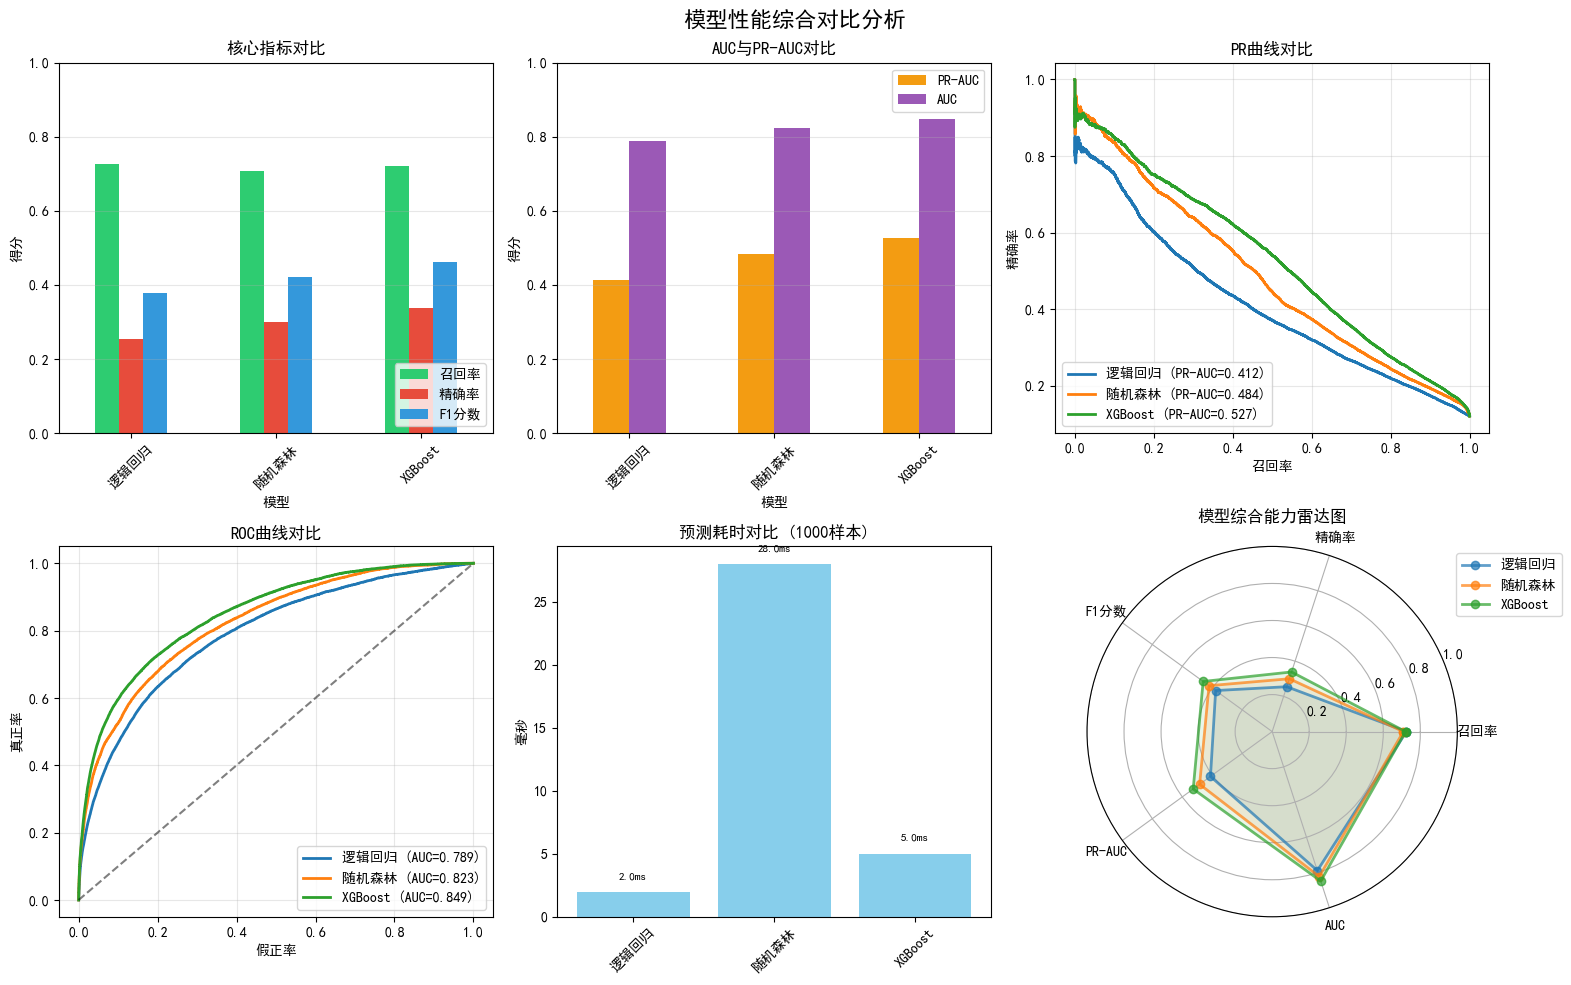

In [51]:

fig = plt.figure(figsize=(16, 10))

# 核心指标对比图
ax1 = plt.subplot(2, 3, 1)
core_df[['召回率', '精确率', 'F1分数']].plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c', '#3498db'])
ax1.set_title('核心指标对比')
ax1.set_ylabel('得分')
ax1.set_ylim(0, 1)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# PR-AUC对比
ax2 = plt.subplot(2, 3, 2)
core_df[['PR-AUC', 'AUC']].plot(kind='bar', ax=ax2, color=['#f39c12', '#9b59b6'])
ax2.set_title('AUC与PR-AUC对比')
ax2.set_ylabel('得分')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

# PR曲线
ax3 = plt.subplot(2, 3, 3)
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_pred_proba)
    pr_auc_value = auc(recall_curve, precision_curve)  # 使用全路径
    ax3.plot(recall_curve, precision_curve, linewidth=2, label=f'{name} (PR-AUC={pr_auc_value:.3f})')
ax3.set_xlabel('召回率')
ax3.set_ylabel('精确率')
ax3.set_title('PR曲线对比')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

# 4. ROC曲线
ax4 = plt.subplot(2, 3, 4)
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc_value = roc_auc_score(y_val, y_pred_proba)
    ax4.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc_value:.3f})')
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax4.set_xlabel('假正率')
ax4.set_ylabel('真正率')
ax4.set_title('ROC曲线对比')
ax4.legend(loc='lower right')
ax4.grid(True, alpha=0.3)

# 模型效率对比
ax5 = plt.subplot(2, 3, 5)
predict_times = []
for name, model in models.items():
    start = time.time()
    model.predict_proba(X_val[:1000])
    end = time.time()
    predict_times.append((end - start) * 1000)  # 毫秒
bars = ax5.bar(core_df.index, predict_times, color='skyblue')
ax5.set_title('预测耗时对比 (1000样本)')
ax5.set_ylabel('毫秒')
ax5.set_xticklabels(core_df.index, rotation=45)
# 添加数值标签
for bar, time_val in zip(bars, predict_times):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{time_val:.1f}ms', ha='center', fontsize=8)

# 业务指标雷达图
ax6 = plt.subplot(2, 3, 6, projection='polar')
categories = ['召回率', '精确率', 'F1分数', 'PR-AUC', 'AUC']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, (name, row) in enumerate(core_df.iterrows()):
    values = row[categories].values.tolist()
    values += values[:1]
    ax6.plot(angles, values, 'o-', linewidth=2, label=name, alpha=0.7)
    ax6.fill(angles, values, alpha=0.1)
ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories)
ax6.set_ylim(0, 1)
ax6.set_title('模型综合能力雷达图')
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.suptitle('模型性能综合对比分析', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:

# XGBoost超参数优化

# 计算精确的类别权重
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

print(f"负样本数: {neg_count:,}")
print(f"正样本数: {pos_count:,}")
print(f"建议scale_pos_weight: {scale_weight:.2f}")

print("\n【训练原始XGBoost模型（默认参数）】")
original_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)
original_xgb_model.fit(X_train, y_train)

# 计算原始模型指标
y_pred_orig = original_xgb_model.predict(X_val)
y_pred_proba_orig = original_xgb_model.predict_proba(X_val)[:, 1]

original_f1 = f1_score(y_val, y_pred_orig)
original_recall = recall_score(y_val, y_pred_orig)
original_precision = precision_score(y_val, y_pred_orig)
original_auc = roc_auc_score(y_val, y_pred_proba_orig)

# 计算PR-AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba_orig)
original_pr_auc = auc(recall_vals, precision_vals)

print(f"  F1: {original_f1:.4f}")
print(f"  召回率: {original_recall:.4f}")
print(f"  精确率: {original_precision:.4f}")
print(f"  AUC: {original_auc:.4f}")
print(f"  PR-AUC: {original_pr_auc:.4f}")

print("开始XGBoost超参数搜索（随机搜索）...")

# 定义XGBoost参数网格
param_grid_xgb = {
    'n_estimators': [350, 400, 450, 500],
    'max_depth': [8, 9, 10, 11],
    'learning_rate': [0.12, 0.15, 0.18],
    'subsample': [0.9, 0.95, 1.0],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'min_child_weight': [1, 2, 3],
    'gamma': [0, 0.05, 0.1],
    'reg_alpha': [0.5, 1.0, 1.5],
    'reg_lambda': [0.5, 1.0, 1.5],
    'scale_pos_weight': [5.5, 5.83, 6.2, 7.29]
}

# 基础模型
base_xgb = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1
)

# 随机搜索
random_search_xgb = RandomizedSearchCV(
    base_xgb,
    param_grid_xgb,
    n_iter=50,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
random_search_xgb.fit(X_train, y_train)
end_time = time.time()

print(f"\n【最佳参数】")
best_params = random_search_xgb.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\n最佳CV F1: {random_search_xgb.best_score_:.4f}")
print(f"搜索时间: {end_time - start_time:.1f}秒")

print("\n【训练优化后XGBoost模型】")

# 准备最佳参数
best_params['random_state'] = 42
best_params['use_label_encoder'] = False
best_params['eval_metric'] = 'logloss'
best_params['verbosity'] = 0
best_params['n_jobs'] = -1

# 训练优化后的模型
final_xgb_model = xgb.XGBClassifier(**best_params)
final_xgb_model.fit(X_train, y_train)

# 评估优化后的模型
y_pred_opt = final_xgb_model.predict(X_val)
y_pred_proba_opt = final_xgb_model.predict_proba(X_val)[:, 1]

optimized_f1 = f1_score(y_val, y_pred_opt)
optimized_recall = recall_score(y_val, y_pred_opt)
optimized_precision = precision_score(y_val, y_pred_opt)
optimized_auc = roc_auc_score(y_val, y_pred_proba_opt)

# 计算PR-AUC
precision_vals_opt, recall_vals_opt, _ = precision_recall_curve(y_val, y_pred_proba_opt)
optimized_pr_auc = auc(recall_vals_opt, precision_vals_opt)

print("\n【优化后XGBoost模型】")
print(f"  F1: {optimized_f1:.4f}")
print(f"  召回率: {optimized_recall:.4f}")
print(f"  精确率: {optimized_precision:.4f}")
print(f"  AUC: {optimized_auc:.4f}")
print(f"  PR-AUC: {optimized_pr_auc:.4f}")

print("【优化效果对比】")

improvement = (optimized_f1 - original_f1) / original_f1 * 100

print(f"{'指标':<12} {'原始模型':<12} {'优化后模型':<12} {'提升':<10}")
print("-"*50)
print(f"{'F1':<12} {original_f1:<12.4f} {optimized_f1:<12.4f} +{improvement:.2f}%")
print(f"{'召回率':<12} {original_recall:<12.4f} {optimized_recall:<12.4f} {(optimized_recall-original_recall)/original_recall*100:+.2f}%")
print(f"{'精确率':<12} {original_precision:<12.4f} {optimized_precision:<12.4f} {(optimized_precision-original_precision)/original_precision*100:+.2f}%")
print(f"{'AUC':<12} {original_auc:<12.4f} {optimized_auc:<12.4f} {(optimized_auc-original_auc)/original_auc*100:+.2f}%")
print(f"{'PR-AUC':<12} {original_pr_auc:<12.4f} {optimized_pr_auc:<12.4f} {(optimized_pr_auc-original_pr_auc)/original_pr_auc*100:+.2f}%")

print("【最终建议】")

if optimized_f1 > original_f1:
    print(f"超参数优化成功！F1提升 {improvement:.2f}%")
    print(f"   推荐使用优化后的XGBoost模型")
    final_model = final_xgb_model
    final_f1 = optimized_f1
else:
    print(f"优化未提升，建议使用原始XGBoost模型")
    final_model = original_xgb_model
    final_f1 = original_f1

print(f"\n最终选择: {'优化后XGBoost' if optimized_f1 > original_f1 else '原始XGBoost'}")
print(f"最终F1分数: {final_f1:.4f}")

负样本数: 527,610
正样本数: 72,390
建议scale_pos_weight: 7.29

【训练原始XGBoost模型（默认参数）】
  F1: 0.4607
  召回率: 0.7201
  精确率: 0.3387
  AUC: 0.8486
  PR-AUC: 0.5272
开始XGBoost超参数搜索（随机搜索）...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

【最佳参数】
  subsample: 0.95
  scale_pos_weight: 5.5
  reg_lambda: 1.5
  reg_alpha: 1.0
  n_estimators: 350
  min_child_weight: 3
  max_depth: 10
  learning_rate: 0.12
  gamma: 0.05
  colsample_bytree: 0.8

最佳CV F1: 0.5033
搜索时间: 1072.9秒

【训练优化后XGBoost模型】

【优化后XGBoost模型】
  F1: 0.5002
  召回率: 0.6147
  精确率: 0.4216
  AUC: 0.8452
  PR-AUC: 0.5283
【优化效果对比】
指标           原始模型         优化后模型        提升        
--------------------------------------------------
F1           0.4607       0.5002       +8.56%
召回率          0.7201       0.6147       -14.65%
精确率          0.3387       0.4216       +24.48%
AUC          0.8486       0.8452       -0.41%
PR-AUC       0.5272       0.5283       +0.20%
【最终建议】
超参数优化成功！F1提升 8.56%
   推荐使用优化后的XGBoost模型

最终选择: 优化后XGBoost
最终F1分数: 0.5002



【最重要的10个预测特征】
          feature  importance
has_valid_contact    0.397885
     prev_success    0.256798
     prev_unknown    0.050763
     has_any_loan    0.040728
          contact    0.035513
      total_loans    0.020151
          quarter    0.018406
 contacted_before    0.012229
      balance_log    0.011929
     prev_failure    0.011192


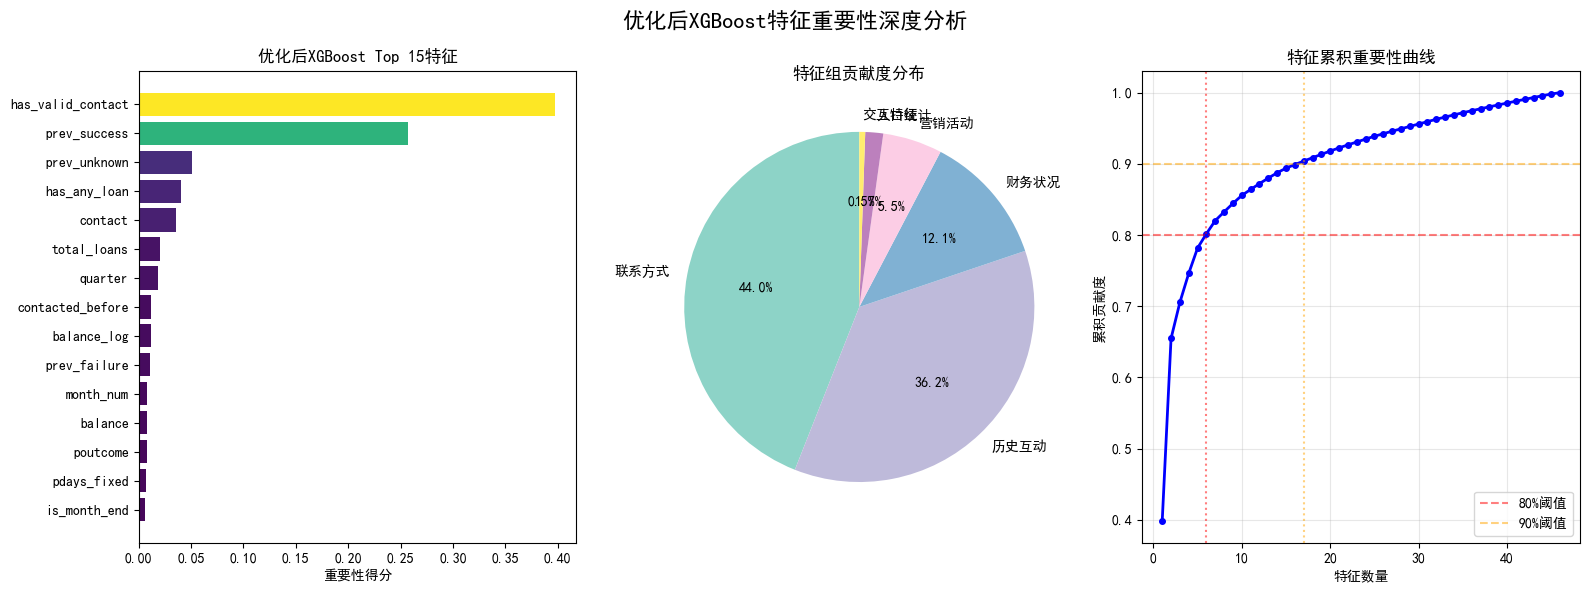

【特征重要性统计】
Top 10特征累积贡献度: 85.6%
达到80%贡献需 6 个特征
达到90%贡献需 17 个特征

【特征组贡献度排序】
  联系方式: 44.0%
  历史互动: 36.2%
  财务状况: 12.1%
  营销活动: 5.5%
  人口统计: 1.7%
  交互特征: 0.5%


In [53]:
# 优化后XGBoost特征重要性深度分析

if 'final_xgb_model' not in dir():
    print("错误：未找到优化后的XGBoost模型！")
else:
    # 获取特征重要性
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n【最重要的10个预测特征】")
    print(feature_importance.head(10).to_string(index=False))

    # 特征分组（根据实际特征更新）
    feature_groups = {
        '联系方式': ['contact', 'contact_score', 'has_valid_contact', 'campaign_contact'],
        '历史互动': ['prev_success', 'prev_failure', 'prev_unknown', 'prev_other', 
                    'previous', 'previous_contacts', 'high_previous', 
                    'contacted_before', 'pdays_fixed', 'days_since_last_contact', 'poutcome'],
        '财务状况': ['balance', 'balance_log', 'balance_negative', 'balance_zero', 'balance_bin',
                    'has_housing_loan', 'has_personal_loan', 'total_loans', 'has_any_loan', 
                    'has_both_loans', 'loan_type', 'loan_type_code', 'housing', 'loan', 'default'],
        '营销活动': ['campaign', 'campaign_high', 'campaign_low', 'campaign_intensity', 
                    'day', 'month_num', 'quarter', 'is_weekend', 'is_month_end'],
        '人口统计': ['age', 'age_group', 'marital', 'education', 'job'],
        '交互特征': ['age_balance', 'job_month']
    }

    # 计算各组重要性
    group_importance = {}
    for group, features in feature_groups.items():
        group_features = [f for f in features if f in feature_importance['feature'].values]
        group_imp = feature_importance[feature_importance['feature'].isin(group_features)]['importance'].sum()
        group_importance[group] = group_imp

    # 创建多图分析
    fig = plt.figure(figsize=(16, 6))

    # Top特征条形图（去掉数字标签）
    ax1 = plt.subplot(1, 3, 1)
    top_features = feature_importance.head(15)
    colors = plt.cm.viridis(top_features['importance'] / top_features['importance'].max())
    bars = ax1.barh(range(len(top_features)), top_features['importance'], color=colors)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['feature'])
    ax1.set_xlabel('重要性得分')
    ax1.set_title('优化后XGBoost Top 15特征')
    ax1.invert_yaxis()

    # 特征分组贡献饼图
    ax2 = plt.subplot(1, 3, 2)
    # 过滤掉贡献为0的组
    valid_groups = {k: v for k, v in group_importance.items() if v > 0}
    colors_group = plt.cm.Set3(np.linspace(0, 1, len(valid_groups)))
    wedges, texts, autotexts = ax2.pie(valid_groups.values(), 
                                         labels=valid_groups.keys(),
                                         autopct='%1.1f%%',
                                         colors=colors_group,
                                         startangle=90)
    ax2.set_title('特征组贡献度分布')

    # 特征累积重要性曲线
    ax3 = plt.subplot(1, 3, 3)
    cumsum = feature_importance['importance'].cumsum() / feature_importance['importance'].sum()
    ax3.plot(range(1, len(cumsum)+1), cumsum, 'b-', linewidth=2, marker='o', markersize=4)
    ax3.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80%阈值')
    ax3.axhline(y=0.9, color='orange', linestyle='--', alpha=0.5, label='90%阈值')
    ax3.set_xlabel('特征数量')
    ax3.set_ylabel('累积贡献度')
    ax3.set_title('特征累积重要性曲线')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    n_80 = np.argmax(cumsum >= 0.8) + 1
    n_90 = np.argmax(cumsum >= 0.9) + 1
    ax3.axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
    ax3.axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
    
    plt.suptitle('优化后XGBoost特征重要性深度分析', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    
    # 输出统计信息
    print("【特征重要性统计】")
    print(f"Top 10特征累积贡献度: {feature_importance.head(10)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
    print(f"达到80%贡献需 {n_80} 个特征")
    print(f"达到90%贡献需 {n_90} 个特征")
    
    print("\n【特征组贡献度排序】")
    for group, imp in sorted(group_importance.items(), key=lambda x: x[1], reverse=True):
        print(f"  {group}: {imp / feature_importance['importance'].sum() * 100:.1f}%")

【特征重要性统计】
Top 10特征累积贡献度: 87.9%
达到80%贡献需 4 个特征
达到90%贡献需 14 个特征

【特征组贡献度排序】
  联系方式: 60.0%
  历史互动: 22.6%
  财务状况: 10.3%
  营销活动: 5.0%
  人口统计: 1.6%
  交互特征: 0.5%

In [55]:

# 使用优化后模型生成测试集预测

# 确保使用优化后的模型
if 'final_xgb_model' not in dir():
    print("错误：未找到优化后的XGBoost模型！")
    print("请先运行超参数优化代码训练模型")
else:
    # 检查测试集是否存在
    if 'X_test' not in dir() or 'test' not in dir():
        print("错误：未找到测试集数据！")
        print("请确保已加载测试集并完成特征工程")
    else:
        # 生成预测概率
        test_pred_proba = final_xgb_model.predict_proba(X_test)[:, 1]
        
        # 计算不同阈值下的F1分数
        thresholds = np.arange(0.3, 0.7, 0.02)
        f1_scores = []
        
        for threshold in thresholds:
            y_pred_thresh = (y_pred_proba_opt >= threshold).astype(int)
            f1 = f1_score(y_val, y_pred_thresh)
            f1_scores.append(f1)
        
        # 找到最优阈值
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        print(f"最优阈值: {best_threshold:.2f}")
        print(f"最优F1分数: {best_f1:.4f}")
        
        # 使用最优阈值进行预测
        test_pred = (test_pred_proba >= best_threshold).astype(int)
        
        # 创建结果DataFrame
        submission = pd.DataFrame({
            'id': test['id'],
            'predicted_probability': test_pred_proba,
            'predicted_label': test_pred,
            'should_contact': test_pred
        })
        
        print("\n【预测结果分布】")
        contact_counts = submission['should_contact'].value_counts()
        for label, count in contact_counts.items():
            contact_type = "建议联系" if label == 1 else "不建议联系"
            print(f"  {contact_type}: {count:,} 人 ({count/len(submission)*100:.1f}%)")
        
        print(f"\n建议联系客户比例: {submission['should_contact'].mean():.2%}")
        
        print("\n【预测概率统计】")
        prob_stats = submission['predicted_probability'].describe()
        print(prob_stats.to_string())
        
        # 客户分层
        submission['segment'] = pd.cut(submission['predicted_probability'],
                                       bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
                                       labels=['低潜力', '中低潜力', '中潜力', '高潜力', '极高潜力'])
        
        print("\n【客户潜力分层】")
        segment_stats = submission.groupby('segment', observed=True)['id'].count()
        for segment, count in segment_stats.items():
            print(f"  {segment}: {count:,} 人 ({count/len(submission)*100:.1f}%)")
        
        # 各潜力分层建议联系比例
        print("\n【各潜力分层建议联系比例】")
        segment_contact = submission.groupby('segment', observed=True)['should_contact'].mean()
        for segment, ratio in segment_contact.items():
            print(f"  {segment}: {ratio:.1%}")
        
        # 高潜力客户详细信息
        print("\n【高潜力客户示例（预测概率Top 10）】")
        top_customers = submission.nlargest(10, 'predicted_probability')[['id', 'predicted_probability', 'segment']]
        print(top_customers.to_string(index=False))
        
        high_potential_count = segment_stats.get('极高潜力', 0) + segment_stats.get('高潜力', 0)
        medium_potential_count = segment_stats.get('中潜力', 0)
        low_potential_count = segment_stats.get('中低潜力', 0) + segment_stats.get('低潜力', 0)
        
        # 基于验证集转化率估算（约12%）
        expected_conversion_rate = y_val.mean()  # 验证集实际转化率

        # 保存结果
        submission.to_csv('prediction_results_optimized.csv', index=False)
        print("\n 预测结果已保存至 prediction_results_optimized.csv")

最优阈值: 0.60
最优F1分数: 0.5179

【预测结果分布】
  不建议联系: 217,657 人 (87.1%)
  建议联系: 32,343 人 (12.9%)

建议联系客户比例: 12.94%

【预测概率统计】
count    250000.000000
mean          0.268331
std           0.256653
min           0.000075
25%           0.061383
50%           0.186964
75%           0.395408
max           0.997911

【客户潜力分层】
  低潜力: 130,216 人 (52.1%)
  中低潜力: 58,206 人 (23.3%)
  中潜力: 29,235 人 (11.7%)
  高潜力: 15,894 人 (6.4%)
  极高潜力: 16,449 人 (6.6%)

【各潜力分层建议联系比例】
  低潜力: 0.0%
  中低潜力: 0.0%
  中潜力: 0.0%
  高潜力: 100.0%
  极高潜力: 100.0%

【高潜力客户示例（预测概率Top 10）】
    id  predicted_probability segment
932796               0.997911    极高潜力
920939               0.997783    极高潜力
913992               0.997749    极高潜力
760390               0.997558    极高潜力
888187               0.997302    极高潜力
789068               0.997174    极高潜力
783458               0.997160    极高潜力
752801               0.997157    极高潜力
888075               0.997148    极高潜力
854718               0.996998    极高潜力

 预测结果已保存至 prediction_results_optimized.csv
